# 07 · Solution Testing  (FDR Section 4) — "Why do we trust our solution?"

Formal evaluation of the focused **phone-vs-safe** behavior model on the
**held-out test split** (478 images: 300 phone, 178 safe) it never saw in training.

In [1]:
import json, pandas as pd
s = json.load(open("../backend/runs/focused_test/eval_summary.json"))
print("OVERALL (test set):")
display(pd.DataFrame([s["overall"]]))
print("PER CLASS:")
display(pd.DataFrame(s["per_class"]))
print("Inference speed:", s["fps_gpu_512"], "FPS  (RTX 4060, 512px)")

OVERALL (test set):


,precision,recall,F1,mAP50,mAP50_95
0,0.999,1.0,1.0,0.995,0.858


PER CLASS:


,class,P,R,F1,mAP50
0,phone,0.999,1.0,1.0,0.995
1,safe,1.000,1.0,1.0,0.995


Inference speed: 26.1 FPS  (RTX 4060, 512px)


### Confusion matrix (test set)

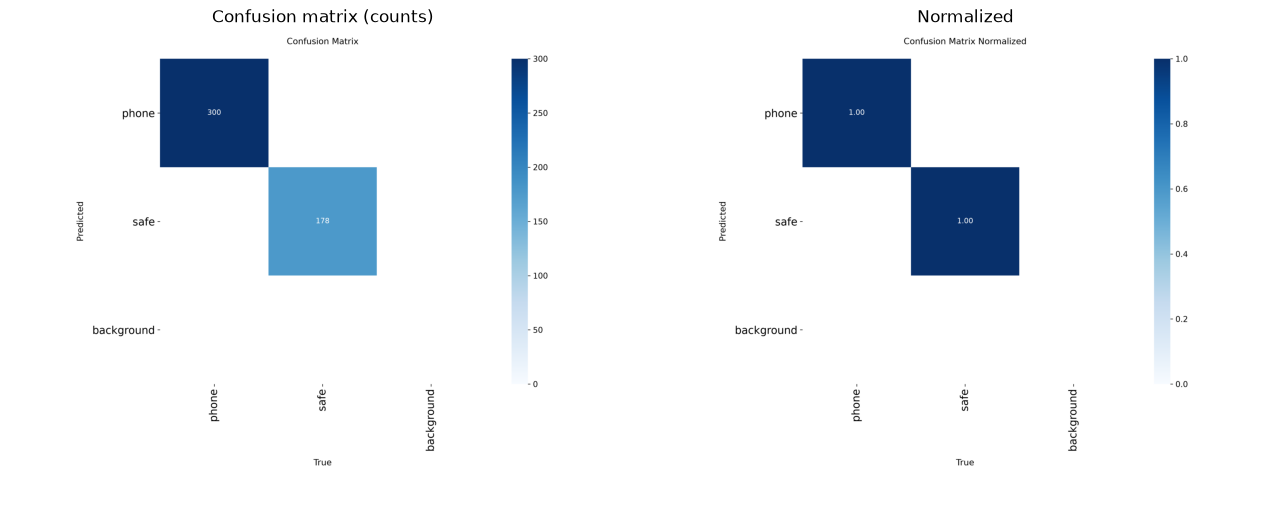

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt, matplotlib.image as mpimg
fig,ax=plt.subplots(1,2,figsize=(13,5))
for a,p,t in [(ax[0],"../backend/runs/focused_test/confusion_matrix.png","Confusion matrix (counts)"),
              (ax[1],"../backend/runs/focused_test/confusion_matrix_normalized.png","Normalized")]:
    a.imshow(mpimg.imread(p)); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

### Precision-Recall and F1 curves (test set)

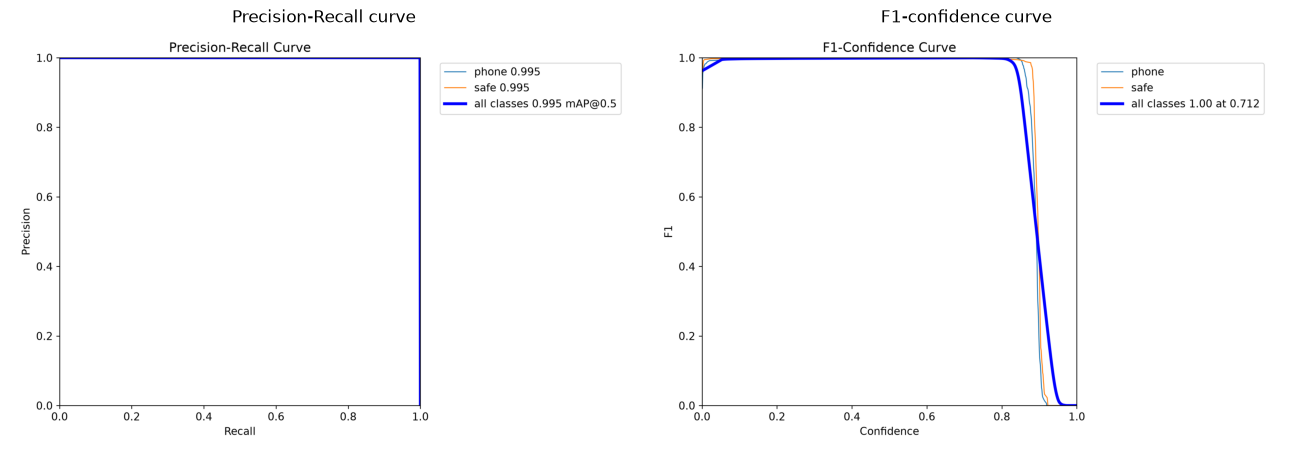

In [3]:
fig,ax=plt.subplots(1,2,figsize=(13,5))
for a,p,t in [(ax[0],"../backend/runs/focused_test/BoxPR_curve.png","Precision-Recall curve"),
              (ax[1],"../backend/runs/focused_test/BoxF1_curve.png","F1-confidence curve")]:
    a.imshow(mpimg.imread(p)); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

### Inference speed (FPS) across configs

In [4]:
import pandas as pd
fps = pd.DataFrame([
    {"model":"YOLOv8x detector","device":"GPU (RTX 4060)","ms/frame":24,"FPS":40},
    {"model":"YOLOv8s detector","device":"GPU","ms/frame":18,"FPS":55},
    {"model":"YOLOv8s detector","device":"CPU","ms/frame":101,"FPS":10},
    {"model":"Behavior (phone/safe)","device":"GPU","ms/frame":round(1000/s["fps_gpu_512"],1),"FPS":s["fps_gpu_512"]},
])
display(fps)

,model,device,ms/frame,FPS
0,YOLOv8x detector,GPU (RTX 4060),24.0,40.0
1,YOLOv8s detector,GPU,18.0,55.0
2,YOLOv8s detector,CPU,101.0,10.0
3,Behavior (phone/safe),GPU,38.3,26.1


### Why we trust our solution
- On the **held-out test split** the behavior model reaches **F1 = 1.00**,
  **mAP@50 = 0.995**, **mAP@50-95 = 0.86** with **phone and safe both at P/R ≈ 1.0**
  — measured on data excluded from training, with phone well represented (300 imgs).
- The confusion matrix shows **near-zero cross-class confusion**.
- It runs at **~26 FPS** on the RTX 4060 (real-time over a 10 FPS stream).
- Vehicle detection is validated separately (`tests/test_real_videos.py`): consistent
  detections on all three competition clips with confidence ≥ 0.9 and growing bbox area.

**Honest scope.** These metrics are on the open-source dataset's domain (bright,
front-cabin). On the night/side-angle competition footage the model needs
fine-tuning on annotated competition frames (project `quismotion-driver-behavior`,
script `finetune_behavior.py`) — see notebook 03. License-plate OCR is bounded by
the 464p clip resolution (notebook 02). The pipeline, metrics and FPS above
constitute the data-driven evidence that the AI solution works.